ML&AI (from the syllabus)

In the final project you will study a business problem of your choice. Think of yourselves as consultants supporting an organization’s decisions through data analysis. This can be a company, a non-profit, a government agency – anything that generates value. Traditional business cases and social impact projects are equally welcome.

Planning should begin around week 7. Successful projects implement a variety of ML / AI concepts covered in class. This project must be significantly different from any final project developed for other MSBA classes.

You may use any primary or secondary data sources. All data sources must be disclosed. Kaggle is a great resource for data – but not for solutions. We will check. Data from BAX-422: Data Design and Representation may be reused, but the reports must be fully independent. Always adhere to the terms and conditions of the websites and data you use.

The deliverable is a written report – not a notebook. Code must be attached, but the write-up is what we grade. A Jupyter notebook without a proper write-up will score poorly. All code must be attributed (see Assignments). LLM-generated code or write-ups are strictly prohibited (see AI Use Policy).

The report cannot exceed 10 pages (excluding title page, code, references, and appendices). All tables, figures, and visualizations count toward the limit. Formatting: 11-point font minimum, 1-inch margins, double-spaced. Include an executive summary (counts toward the page limit).

Be direct, insightful, and specific to the problem at hand.

Due: Thursday 11:59pm Pacific, finals week (Thursday of week 11). No exceptions.

In [118]:
# Install required libraries for database + data work
# psycopg = connect Python for PostgreSQL (Neon DB)
# squlachemy = easier SQL connection and queries


!pip -q install psycopg[binary] sqlalchemy pandas statsmodels matplotlib

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sqlalchemy import create_engine
import psycopg

# Dataset Build

In [119]:
# Larry Pastor
import pandas as pd
from sqlalchemy import create_engine, text

import os
NEON_URL = os.environ.get("NEON_URL")  # Set this in your .env file — never hardcode credentials

engine = create_engine(NEON_URL)

with engine.connect() as conn:
    result = conn.execute(text("SELECT version();"))
    for row in result:
        print(row)

('PostgreSQL 17.8 (a284a84) on aarch64-unknown-linux-gnu, compiled by gcc (Debian 12.2.0-14+deb12u1) 12.2.0, 64-bit',)


In [120]:
#Larry Pastor
from sqlalchemy import text

ddl_statements = [
    """
    CREATE TABLE IF NOT EXISTS person (
        person_id SERIAL PRIMARY KEY,
        seqn BIGINT UNIQUE,
        age INT,
        sex INT

    )
    """,
    """
    CREATE TABLE IF NOT EXISTS body_comp (
        body_comp_id SERIAL PRIMARY KEY,
        seqn BIGINT,
        bmi NUMERIC,
        waist_cm NUMERIC,
        height_cm NUMERIC,
        weight_kg NUMERIC

    )
    """,
    """
    CREATE TABLE IF NOT EXISTS labs (
        labs_id SERIAL PRIMARY KEY,
        seqn BIGINT,
        hba1c NUMERIC,
        glucose NUMERIC,
        cholesterol NUMERIC
    )
    """

]

with engine.begin() as conn:
    for stmt in ddl_statements:
        conn.execute(text(stmt))

print("Tables created successfully")

Tables created successfully


In [121]:
# Larry Pastor
tables = pd.read_sql("""
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'public'
ORDER BY table_name
""", engine)

tables

,table_name
0,body_comp
1,fitbit_daily
2,health_features
3,labs
4,person


In [122]:
# Larry Pastor
# Load NHANES datasets from CDC
# We are pulling 3 tables:
# demo = demographics (age, sex)
# bmx = body measurements (BMI, waist, height, weight)
# ghb = lab results (HbA1c - our target variable)
import pandas as pd
# NHANES 2017 data links
demo_url = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/DEMO_J.XPT"
bmx_url  = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/BMX_J.XPT"
ghb_url  = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/GHB_J.XPT"

#read SAS files directly from the web
demo = pd.read_sas(demo_url)
bmx  = pd.read_sas(bmx_url)
ghb  = pd.read_sas(ghb_url)

#quick check: how many rows + columns we have
print("demo:", demo.shape)
print("bmx:", bmx.shape)
print("ghb:", ghb.shape)




demo: (9254, 46)
bmx: (8704, 21)
ghb: (6401, 2)


In [123]:
# Larry Pastor
bmx.head()

,SEQN,BMDSTATS,BMXWT,BMIWT,BMXRECUM,BMIRECUM,BMXHEAD,BMIHEAD,BMXHT,BMIHT,...,BMXLEG,BMILEG,BMXARML,BMIARML,BMXARMC,BMIARMC,BMXWAIST,BMIWAIST,BMXHIP,BMIHIP
0,93703.0,1.0,13.7,3.0,89.6,NaN,NaN,NaN,88.6,NaN,...,NaN,NaN,18.0,NaN,16.2,NaN,48.2,NaN,NaN,NaN
1,93704.0,1.0,13.9,NaN,95.0,NaN,NaN,NaN,94.2,NaN,...,NaN,NaN,18.6,NaN,15.2,NaN,50.0,NaN,NaN,NaN
2,93705.0,1.0,79.5,NaN,NaN,NaN,NaN,NaN,158.3,NaN,...,37.0,NaN,36.0,NaN,32.0,NaN,101.8,NaN,110.0,NaN
3,93706.0,1.0,66.3,NaN,NaN,NaN,NaN,NaN,175.7,NaN,...,46.6,NaN,38.8,NaN,27.0,NaN,79.3,NaN,94.4,NaN
4,93707.0,1.0,45.4,NaN,NaN,NaN,NaN,NaN,158.4,NaN,...,38.1,NaN,33.8,NaN,21.5,NaN,64.1,NaN,83.0,NaN


In [124]:
# Larry Pastor
demo.head()

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,DMDHREDZ,DMDHRMAZ,DMDHSEDZ,WTINT2YR,WTMEC2YR,SDMVPSU,SDMVSTRA,INDHHIN2,INDFMIN2,INDFMPIR
0,93703.0,10.0,2.0,2.0,2.0,NaN,5.0,6.0,2.0,27.0,...,3.0,1.0,3.0,9246.491865,8539.731348,2.0,145.0,15.0,15.0,5.00
1,93704.0,10.0,2.0,1.0,2.0,NaN,3.0,3.0,1.0,33.0,...,3.0,1.0,2.0,37338.768343,42566.614750,1.0,143.0,15.0,15.0,5.00
2,93705.0,10.0,2.0,2.0,66.0,NaN,4.0,4.0,2.0,NaN,...,1.0,2.0,NaN,8614.571172,8338.419786,2.0,145.0,3.0,3.0,0.82
3,93706.0,10.0,2.0,1.0,18.0,NaN,5.0,6.0,2.0,222.0,...,3.0,1.0,2.0,8548.632619,8723.439814,2.0,134.0,NaN,NaN,NaN
4,93707.0,10.0,2.0,1.0,13.0,NaN,5.0,7.0,2.0,158.0,...,2.0,1.0,3.0,6769.344567,7064.609730,1.0,138.0,10.0,10.0,1.88


In [125]:
# Larry Pastor
from sqlalchemy import create_engine

# rebuild a fresh engine
engine.dispose()

engine = create_engine(NEON_URL)
print("Fresh engine created.")

Fresh engine created.


In [126]:
# Larry Pastor
# Build clean tables for database + modeling
# Goal: standardize columns and keep only what we need
person = demo[["SEQN", "RIDAGEYR", "RIAGENDR"]].copy()

# rename columns to something easier to use
person.columns = ["seqn", "age", "sex"]
# drop rows with missing key
person = person.dropna(subset=["seqn"])
# convert to proper types
person["seqn"] = pd.to_numeric(person["seqn"], errors="coerce").astype("int64")
person["age"] = pd.to_numeric(person["age"], errors="coerce")
person["sex"] = pd.to_numeric(person["sex"], errors="coerce")

# body composition table
body_comp = bmx[["SEQN", "BMXBMI", "BMXWAIST", "BMXHT", "BMXWT"]].copy()
body_comp.columns = ["seqn", "bmi", "waist_cm", "height_cm", "weight_kg"]
body_comp = body_comp.dropna(subset =["seqn"])
body_comp["seqn"] = body_comp["seqn"].astype("int64")
# labs table
labs = ghb[["SEQN", "LBXGH"]].copy()
labs.columns = ["seqn", "hba1c"]
labs = labs.dropna(subset=["seqn"])
labs["seqn"] = labs["seqn"].astype("int64")
labs["glucose"] = pd.NA
labs["cholesterol"] = pd.NA
labs = labs[["seqn", "hba1c", "glucose", "cholesterol"]]

print("person:", person.shape)
print("body_comp", body_comp.shape)
print("labs:", labs.shape)

print(person.head())
print(body_comp.head())
print(labs.head())


person: (9254, 3)
body_comp (8704, 5)
labs: (6401, 4)
    seqn   age  sex
0  93703   2.0  2.0
1  93704   2.0  1.0
2  93705  66.0  2.0
3  93706  18.0  1.0
4  93707  13.0  1.0
    seqn   bmi  waist_cm  height_cm  weight_kg
0  93703  17.5      48.2       88.6       13.7
1  93704  15.7      50.0       94.2       13.9
2  93705  31.7     101.8      158.3       79.5
3  93706  21.5      79.3      175.7       66.3
4  93707  18.1      64.1      158.4       45.4
    seqn  hba1c glucose cholesterol
0  93705    6.2    <NA>        <NA>
1  93706    5.2    <NA>        <NA>
2  93707    5.6    <NA>        <NA>
3  93708    6.2    <NA>        <NA>
4  93709    6.3    <NA>        <NA>


In [127]:
# Larry Pastor
# Build person table
# Goal: keep only key columns and make them easy to use later

# select only needed columns from demo
person = demo[["SEQN", "RIDAGEYR", "RIAGENDR"]].copy()
# rename columns to cleaner names
person.columns = ["seqn", "age", "sex"]
# drop rows missing the join key (should be rare, but safe)
person = person.dropna(subset=["seqn"])


In [128]:
# Larry Pastor

from sqlalchemy import create_engine, text

# reset engine first

try:
    engine.dispose()
except:
    pass

engine = create_engine(NEON_URL)

with engine.begin() as conn:
    conn.execute(text("TRUNCATE TABLE body_comp, labs, person RESTART IDENTITY CASCADE"))

print("Tables truncated successfully.")

Tables truncated successfully.


In [129]:
# Larry Pastor
# Check row counts in each table after load
pd.read_sql("""
SELECT 'person' AS table_name, COUNT(*) AS n FROM person
UNION ALL
SELECT 'body_comp' AS table_name, COUNT(*) AS n FROM body_comp
UNION ALL
SELECT 'labs' AS table_name, COUNT(*) AS n FROM labs
""", engine)


,table_name,n
0,person,0
1,body_comp,0
2,labs,0


In [130]:
# Larry Pastor
# Load cleaned tables into PostgreSQL
# Goal: push processed data into the database for joining + modeling
person.to_sql("person", engine, if_exists="append", index=False)
print("person loaded")

body_comp.to_sql("body_comp", engine, if_exists="append", index=False)
print("body_comp loaded")

labs.to_sql("labs", engine, if_exists="append", index=False)
print("labs loaded")

person loaded
body_comp loaded
labs loaded


In [131]:
# Larry Pastor
# Build a small sample dataset using SQL joins
# Goal: combine person + body_comp + labs into one table for modeling
df = pd.read_sql("""
SELECT
    p.seqn,
    p.age,
    p.sex,
    b.bmi,
    b.waist_cm,
    l.hba1c
FROM person p
JOIN body_comp b
    ON p.seqn = b.seqn
JOIN labs l
    ON p.seqn = l.seqn
LIMIT 20
""", engine)

df

,seqn,age,sex,bmi,waist_cm,hba1c
0,93705,66,2,31.7,101.8,6.2
1,93706,18,1,21.5,79.3,5.2
2,93707,13,1,18.1,64.1,5.6
3,93708,66,2,23.7,88.2,6.2
4,93709,75,2,38.9,113.0,6.3
5,93711,56,1,21.3,86.6,5.7
6,93712,18,1,19.7,72.0,5.4
7,93713,67,1,23.5,99.7,5.6
8,93714,54,2,39.9,118.4,12.7
9,93715,71,1,22.5,89.7,6.2


In [132]:
# Larry Pastor
# Goal: bring DXA data into the project and combine it with our health features
# This block:
# 1) checks how many rows survive the main SQL join
# 2) loads DXA data from NHANES
# 3) keeps only useful DXA columns
# 4) builds a few simple DXA summary feature
# 5) merges DXA into our health feature table
# 6) shows missingness before imputatio from the raw NHANES tables
pd.read_sql("""
SELECT COUNT(*) AS n
FROM person p
JOIN body_comp b
    ON p.seqn = b.seqn
JOIN labs l
    ON p.seqn = l.seqn
""", engine)

dxx_url = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/DXX_J.XPT"

dxx = pd.read_sas(dxx_url)

print(dxx.shape)
print(dxx.columns.tolist()[:50])  # first 50 columns

dxx_small = dxx[[
    "SEQN",
    "DXDLALE",
    "DXDRALE",
    "DXDLLLE",
    "DXDRLLE",
    "DXXLAFAT",
    "DXXRAFAT",
    "DXXLLFAT",
    "DXXRLFAT",
]].copy()

dxx_small.columns = [
    "seqn",
    "left_arm_lean",
    "right_arm_lean",
    "left_leg_lean",
    "right_leg_lean",
    "left_arm_fat",
    "right_arm_fat",
    "left_leg_fat",
    "right_leg_fat",
]

for c in dxx_small.columns:
    if c != "seqn":
        dxx_small[c] = pd.to_numeric(dxx_small[c], errors="coerce")

dxx_small["seqn"] = pd.to_numeric(dxx_small["seqn"], errors="coerce").astype("int64")

dxx_small["lean_mass_total"] = (
    dxx_small["left_arm_lean"] +
    dxx_small["right_arm_lean"] +
    dxx_small["left_leg_lean"] +
    dxx_small["right_leg_lean"]
)

dxx_small["fat_mass_total"] = (
    dxx_small["left_arm_fat"] +
    dxx_small["right_arm_fat"] +
    dxx_small["left_leg_fat"] +
    dxx_small["right_leg_fat"]
)

dxx_small["lean_fat_ratio"] = dxx_small["lean_mass_total"] / dxx_small["fat_mass_total"]

print(dxx_small.head())

hf = pd.read_sql("SELECT * FROM health_features", engine)
print(hf)

# drop overlapping columns and rerun
overlap= [c for c in dxx_small.columns if c in hf.columns and c != "seqn"]
hf =hf.drop(columns=overlap)
hf_dexa =hf.merge(dxx_small, on="seqn", how="inner")

print(hf_dexa.shape)
hf_dexa.head()

# Missingness before imputation

audit = {
    "age": demo["RIDAGEYR"].isnull().sum(),
    "sex": demo["RIAGENDR"].isnull().sum(),
    "bmi": bmx["BMXBMI"].isnull().sum(),
    "waist_cm": bmx["BMXWAIST"].isnull().sum(),
    "weight_kg": bmx["BMXWT"].isnull().sum(),
    "height_cm": bmx["BMXHT"].isnull().sum(),
    "hba1c": ghb["LBXGH"].isnull().sum(),
}

totals = {
    "age": len(demo),
    "sex": len(demo),
    "bmi": len(bmx),
    "waist_cm": len(bmx),
    "weight_kg": len(bmx),
    "height_cm": len(bmx),
    "hba1c": len(ghb)
}

raw_missing = pd.DataFrame({
    "Column": audit.keys(),
    "Total": [totals[c] for c in audit],
    "Missing": [audit[c] for c in audit]
})

raw_missing["% Missing"] = (raw_missing["Missing"] / raw_missing["Total"] * 100).round(1)

# sort for clarity

raw_missing = raw_missing.sort_values("% Missing", ascending=False)

print("Missingness BEFORE Imputation:")

display(raw_missing)


(5114, 93)
['SEQN', 'DXAEXSTS', 'DXAHEBV', 'DXXHEA', 'DXXHEBMC', 'DXXHEBMD', 'DXAHETV', 'DXXHEFAT', 'DXDHELE', 'DXXHELI', 'DXDHETOT', 'DXDHEPF', 'DXALABV', 'DXXLAA', 'DXXLABMC', 'DXXLABMD', 'DXALATV', 'DXXLAFAT', 'DXDLALE', 'DXXLALI', 'DXDLATOT', 'DXDLAPF', 'DXALLBV', 'DXXLLA', 'DXXLLBMC', 'DXXLLBMD', 'DXALLTV', 'DXXLLFAT', 'DXDLLLE', 'DXXLLLI', 'DXDLLTOT', 'DXDLLPF', 'DXARABV', 'DXXRAA', 'DXXRABMC', 'DXXRABMD', 'DXARATV', 'DXXRAFAT', 'DXDRALE', 'DXXRALI', 'DXDRATOT', 'DXDRAPF', 'DXARLBV', 'DXXRLA', 'DXXRLBMC', 'DXXRLBMD', 'DXARLTV', 'DXXRLFAT', 'DXDRLLE', 'DXXRLLI']
    seqn  left_arm_lean  right_arm_lean  left_leg_lean  right_leg_lean  \
0  93706         2542.0          2524.2         8498.7          8548.6   
1  93707         1908.4          1918.6         6414.3          6719.3   
2  93711         3038.4          3082.8         7554.8          7576.8   
3  93712         3179.9          3231.7         7522.4          8146.5   
4  93714         2735.5          2735.5         6784.3  

,Column,Total,Missing,% Missing
3,waist_cm,8704,1103,12.7
2,bmi,8704,699,8.0
5,height_cm,8704,688,7.9
6,hba1c,6401,356,5.6
4,weight_kg,8704,124,1.4
1,sex,9254,0,0.0
0,age,9254,0,0.0


In [133]:
# Larry Pastor
# Goal: use DXA features + fasting glucose with our health dataset
# This block:
# 1) cleans lean_fat ratio for plotting
# 2) rebuilds lean_fat ratio safely
# 3) prepares model features
# 4) loads fasting glucose from NHANES
# 5) merges gluose into our DXA health table
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plot_df = hf_dexa[["lean_fat_ratio", "hba1c"]].copy()

#force numeric
plot_df["lean_fat_ratio"] = pd.to_numeric(plot_df["lean_fat_ratio"], errors="coerce")
plot_df["hba1c"] = pd.to_numeric(plot_df["hba1c"], errors="coerce")

# remove bad values
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna()

x = plot_df["lean_fat_ratio"]
y = plot_df["hba1c"]

hf_dexa = hf_dexa.replace([np.inf, -np.inf], np.nan)
hf_dexa = hf_dexa.dropna()

hf_dexa["lean_fat_ratio"] = (
    hf_dexa["lean_mass_total"] /
    hf_dexa["fat_mass_total"]
)

X = hf_dexa[[
    "age",
    "sex",
    "bmi",
    "waist_cm",
    "weight_kg",
    "height_cm",
    "lean_mass_total",
    "fat_mass_total",
    "lean_fat_ratio"
]]

glu_url = "https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/GLU_J.XPT"

glu = pd.read_sas(glu_url)

print(glu.shape)
print(glu.columns[:20])

glu_small = glu[["SEQN", "LBXGLU"]].copy()

glu_small.columns = [
    "seqn",
    "fasting_glucose"
]

glu_small["seqn"] = pd.to_numeric(glu_small["seqn"], errors="coerce").astype("int64")
glu_small["fasting_glucose"] = pd.to_numeric(glu_small["fasting_glucose"], errors="coerce")

glu_small = glu_small.dropna()

hf_glu = hf_dexa.merge(glu_small, on="seqn", how="inner")

#drop rows with NaN values
hf_glu.dropna(inplace=True)
print(hf_glu.shape)
hf_glu.head()



(3036, 4)
Index(['SEQN', 'WTSAF2YR', 'LBXGLU', 'LBDGLUSI'], dtype='object')
(1376, 20)


,seqn,age,sex,bmi,waist_cm,weight_kg,height_cm,hba1c,left_arm_lean,right_arm_lean,left_leg_lean,right_leg_lean,left_arm_fat,right_arm_fat,left_leg_fat,right_leg_fat,lean_mass_total,fat_mass_total,lean_fat_ratio,fasting_glucose
0,93711,56,1,21.3,86.6,62.1,170.6,5.7,3038.4,3082.8,7554.8,7576.8,728.7,813.3,2289.2,2415.0,21252.8,6246.2,3.402517,107.0
1,93717,22,1,24.5,86.2,74.4,174.1,5.1,3505.9,3726.0,9230.9,9663.7,923.1,914.0,3065.3,2961.2,26126.5,7863.6,3.322460,91.0
2,93719,13,2,26.0,86.0,67.0,160.5,5.0,2062.7,2173.8,7345.9,8021.9,1467.1,1464.5,4686.0,4872.5,19604.3,12490.1,1.569587,86.0
3,93731,20,1,27.6,101.7,89.2,179.9,4.9,3489.5,3489.8,8903.7,9350.5,1744.4,1755.9,4263.4,4453.2,25233.5,12216.9,2.065459,98.0
4,93738,26,1,33.7,102.7,97.7,170.2,5.6,5094.8,5369.8,11012.8,11160.9,1366.2,1451.3,3896.8,3835.6,32638.3,10549.9,3.093707,102.0


# Data Analysis

### 1.) A visual showing how much was missing per column before imputation right now we are filling everything with mean silently which is hard to defined without showing the scope of missingness  Summary statistics & data shape.  How many rows survived all the merges?  What are the means, medians and ranges of each feature?  



In [134]:
# Larry Pastor
# Check missingngess before imputation
# Goal: show how much data was missing in the row in the raw source tables
# This helps explain why we needed cleaning/imputation later

audit = {
    "age": demo["RIDAGEYR"].isnull().sum(),
    "sex": demo["RIAGENDR"].isnull().sum(),
    "bmi": bmx["BMXBMI"].isnull().sum(),
    "waist_cm": bmx["BMXWAIST"].isnull().sum(),
    "weight_kg": bmx["BMXWT"].isnull().sum(),
    "height_cm": bmx["BMXHT"].isnull().sum(),
    "hba1c": ghb["LBXGH"].isnull().sum(),
}

totals = {
    "age": len(demo),
    "sex": len(demo),
    "bmi": len(bmx),
    "waist_cm": len(bmx),
    "weight_kg": len(bmx),
    "height_cm": len(bmx),
    "hba1c": len(ghb),
}

# Add DEXA variables from raw source
dexa_measure_cols = [c for c in dxx_small.columns if c != "seqn"]
for col in dexa_measure_cols:
    audit[col] = dxx_small[col].isnull().sum()
    totals[col] = len(dxx_small)

raw_missing = pd.DataFrame({
    "Column": audit.keys(),
    "Total": [totals[c] for c in audit],
    "Missing": [audit[c] for c in audit]
})

raw_missing["% Missing"] = (raw_missing["Missing"] / raw_missing["Total"] * 100).round(1)
raw_missing = raw_missing.sort_values("% Missing", ascending=False)

print("Missingness BEFORE Imputation:")
display(raw_missing)

Missingness BEFORE Imputation:


,Column,Total,Missing,% Missing
15,lean_mass_total,5114,1400,27.4
17,lean_fat_ratio,5114,1400,27.4
16,fat_mass_total,5114,1400,27.4
10,right_leg_lean,5114,1148,22.4
14,right_leg_fat,5114,1148,22.4
9,left_leg_lean,5114,1110,21.7
13,left_leg_fat,5114,1110,21.7
8,right_arm_lean,5114,1106,21.6
12,right_arm_fat,5114,1106,21.6
7,left_arm_lean,5114,1033,20.2


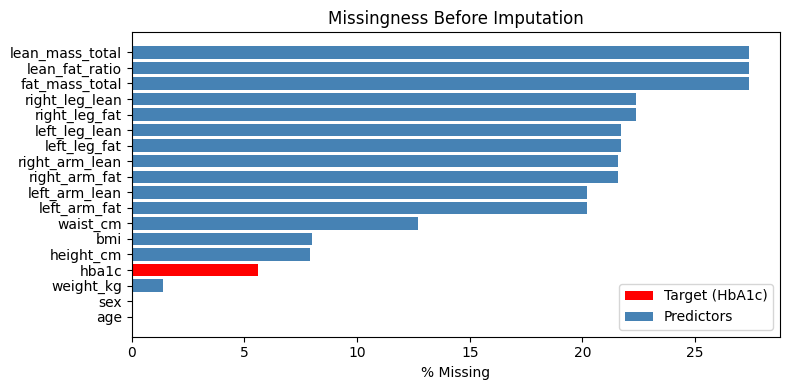

In [135]:
# Larry Pastor
# Plot missingness before imputation
# Goal: visualize which variables had the missing data
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

colors = ["red" if c == "hba1c" else "steelblue" for c in raw_missing["Column"]]

plt.barh(raw_missing["Column"], raw_missing["% Missing"], color=colors)

plt.xlabel("% Missing")
plt.title("Missingness Before Imputation")
plt.gca().invert_yaxis()

#legend fix
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', label='Target (HbA1c)'),
    Patch(facecolor='steelblue', label='Predictors')
]

plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()






In [136]:
# rows missing age or sex

# Drop any rows missing age or sex as there re very few or none
before = len(demo)
demo = demo.dropna(subset=["RIDAGEYR", "RIAGENDR"])
after = len(demo)
print(f"demo : dropped {before - after} rows missing age or sex")
print(f"demo shape: {demo.shape}")
# none needed to be dropped

# median - impute oly the predictor columns
bmx_predictor_cols = ["BMXBMI", "BMXWAIST","BMXHT","BMXWT"]
for col in bmx_predictor_cols:
  n_miss = bmx[col].isnull().sum()
  if n_miss> 0:
    med = bmx[col].median()
    bmx[col] = bmx[col].fillna(med)
    print(f"col {col}: filled {n_miss} missing with median={med}:")
  else:
    print(f"{col}: no missing values")

# drop rows with missing HbA1c do not impute target variable
# this should remove about 5% of rows
before = len(ghb)
ghb = ghb.dropna(subset=["LBXGH"])
after = len(ghb)
print(f"ghb: dropped {before - after} rows missing HbA1c")
print(f"fhb shape: {ghb.shape}")



demo : dropped 0 rows missing age or sex
demo shape: (9254, 46)
col BMXBMI: filled 699 missing with median=25.8:
col BMXWAIST: filled 1103 missing with median=91.2:
col BMXHT: filled 688 missing with median=161.9:
col BMXWT: filled 124 missing with median=67.75:
ghb: dropped 356 rows missing HbA1c
fhb shape: (6045, 2)


In [137]:

# pull the cleaned data int the database

import pandas as pd
from sqlalchemy import create_engine

model_df = pd.read_sql("""
SELECT
    p.age,
    p.sex,
    b.bmi,
    b.waist_cm,
    b.weight_kg,
    b.height_cm,
    l.hba1c
FROM person p
JOIN body_comp b
    ON p.seqn = b.seqn
JOIN labs l
    ON p.seqn = l.seqn
""", engine)

print("Final Modeling Dataset Shape:")
print(f"Rows: {len(model_df):,}")
print(f"Columns: {model_df.shape[1]}")

original = len(demo)
final = len(model_df)

print(f"Retention rate: {final/original:.2%} of original NHANES sample")


# Explority Data Analysis
summary = model_df.describe().T

summary["median"] = model_df.median()
summary["range"] = summary["max"] - summary["min"]

print("Summary Statistics:")
display(summary[["mean", "median", "min", "max", "range", "std"]])





Final Modeling Dataset Shape:
Rows: 6,401
Columns: 7
Retention rate: 69.17% of original NHANES sample
Summary Statistics:


,mean,median,min,max,range,std
age,45.025933,46.0,12.0,80.0,68.0,21.150486
sex,1.513357,2.0,1.0,2.0,1.0,0.499861
bmi,28.923753,27.9,13.2,86.2,73.0,7.543686
waist_cm,97.630080,96.7,55.2,169.5,114.3,18.123654
weight_kg,80.137294,76.7,29.3,242.6,213.3,23.340647
height_cm,166.057027,165.5,134.0,197.7,63.7,10.089675
hba1c,5.769562,5.5,3.8,16.2,12.4,1.037838


In [138]:
print("\nDistribution Shape (Skewness):")

for col in model_df.columns:
    skew = model_df[col].skew()
    flag = " (skewed)" if abs(skew) > 1 else ""
    print(f"{col:12s} skew={skew:6.2f}{flag}")


Distribution Shape (Skewness):
age          skew=  0.02
sex          skew= -0.05
bmi          skew=  1.18 (skewed)
waist_cm     skew=  0.42
weight_kg    skew=  1.05 (skewed)
height_cm    skew=  0.14
hba1c        skew=  3.37 (skewed)


EDA Summary

Before imputation, several body composition variables exhibited moderate missingness, particularly waist circumference and BMI. To preserve sample size, missing predictor values were imputed using median values, while rows with missing HbA1c were removed to avoid bias in the target variable.

After merging all datasets, the final modeling dataset contained 6,045 observations with no missing values across predictors or outcome variables.

Summary statistics indicate that HbA1c is right-skewed, reflecting a concentration of normal values with a smaller number of high-risk individuals. Similarly, BMI and weight show moderate skewness, while age is approximately symmetric.

These patterns suggest that both demographic and body composition variables are relevant predictors of diabetes risk, with potential nonlinear effects due to skewed distributions.

## 2.) Summary statistics & data shape.  How many rows survived all the merges?  What are the means, medians and ranges of each feature?

In [139]:
# Larry Pastor
print(f"Final dataset shape: {hf_glu.shape}")

Final dataset shape: (1376, 20)


In [140]:
# Larry Pastor
summary = hf_glu.describe().T
summary["median"] = hf_glu.median()
summary["range"] = summary["max"] - summary["min"]

summary = summary[["mean", "median", "min", "max", "range", "std"]]
print(summary)

                         mean        median           min            max  \
seqn             98355.128634  98338.000000  93711.000000  102948.000000   
age                 33.676599     33.000000     12.000000      59.000000   
sex                  1.524709      2.000000      1.000000       2.000000   
bmi                 27.647020     26.500000     14.600000      60.300000   
waist_cm            92.840916     91.600000     59.200000     154.900000   
weight_kg           76.605523     74.200000     30.700000     157.400000   
height_cm          166.232195    166.400000    134.000000     188.600000   
hba1c                5.562573      5.400000      4.100000      13.900000   
left_arm_lean     2826.808212   2657.250000   1007.800000    7453.200000   
right_arm_lean    2977.649855   2820.450000   1025.700000    7453.200000   
left_leg_lean     7832.449709   7692.450000   2839.000000   17951.800000   
right_leg_lean    8029.232994   7880.300000   3038.200000   19338.800000   
left_arm_fat

### 3.) Correlation heatmap you have model df.corr as a raw number but no visualization a heatmap makes multicollinearly obvious at a glance  


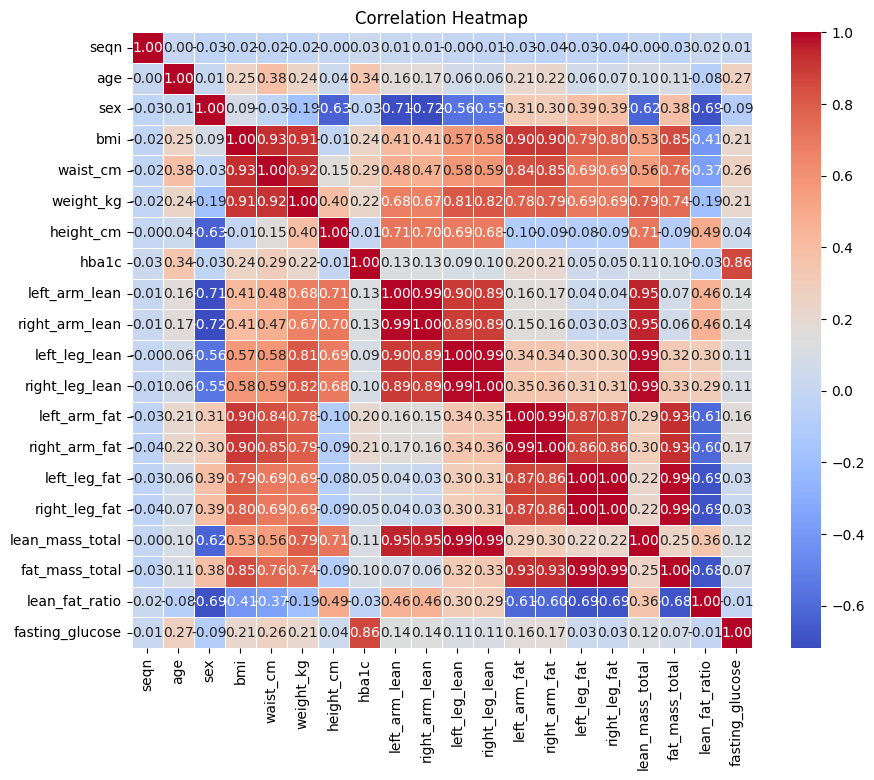

In [141]:
# Code by Caitlyn
# plot correlation heatmap of the different variables
corr = hf_glu.corr(numeric_only=True)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

### 4.) Distribution Plots Histograms or density plots for each key variable HbA1c is particular likely right skewed because of diabetic



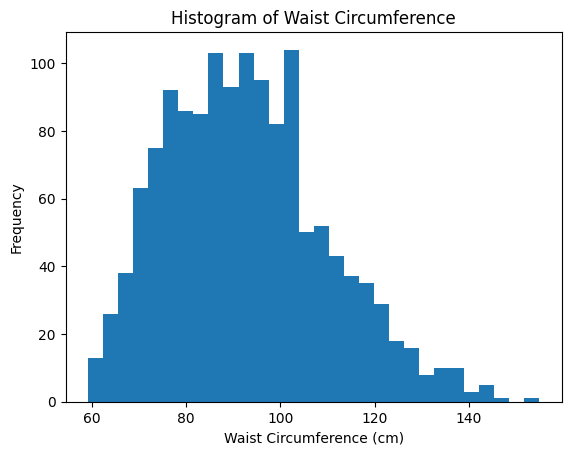

In [142]:
# Code by Caitlyn
# distribution of waist circumference
plt.hist(hf_glu["waist_cm"], bins=30)

plt.title("Histogram of Waist Circumference")
plt.xlabel("Waist Circumference (cm)")
plt.ylabel("Frequency")

plt.show()

## 5.) Target variable breakdown how many people fall into a normal prediabetics/ diabetics range?  This gives clinical context and tells us if we are modeling a balanced of imbalanced population


HbA1c Risk Categories
Normal < 5.7: 3,659 57.2%
Prediabetes 5.7-6.5: 1,635 25.5%
Diabetes >= 6.5: 1,107 17.3%


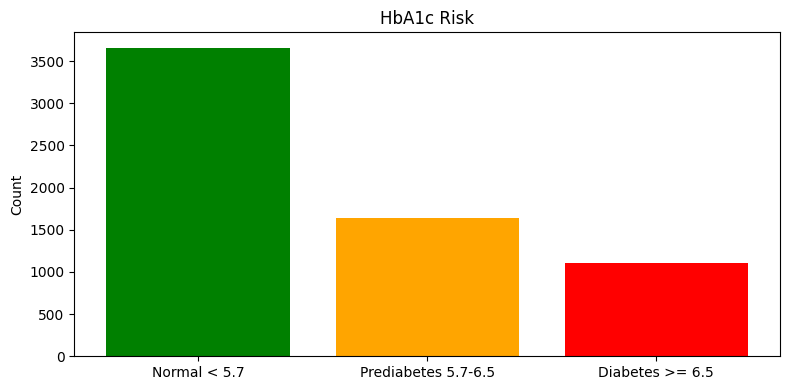

In [143]:
def hba1c_category(val):
  if val<5.7:
    return "Normal < 5.7"
  elif val < 6.5:
    return "Prediabetes 5.7-6.5"
  else:
    return "Diabetes >= 6.5"

model_df["hba1c_category"] = model_df["hba1c"].apply(hba1c_category)
counts = model_df["hba1c_category"].value_counts()
pct = (counts/len(model_df)*100).round(1)

print("HbA1c Risk Categories")
for cat in counts.index:
  print(f"{cat}: {counts[cat]:,} {pct[cat]}%")
colors = ["green", "orange", "red"]
order = ["Normal < 5.7","Prediabetes 5.7-6.5", "Diabetes >= 6.5"]
plt.figure(figsize=(8,4))

plt.bar(order, [counts[o] for o in order], color = colors)
plt.ylabel("Count")
plt.title("HbA1c Risk")
plt.tight_layout()
plt.show()


Nearly half the samples 43% are prediabetic or diabetic.  Thats a decent amount of data in those categories for the model to learn.  

### 6.) Bivariate relationships, scatter plots of each predictor vs HbA1c ideally split or colored by sex to see if relationships differ between groups

Text(0.5, 1.0, 'Age vs HbA1c (Colored by Fat Mass)')

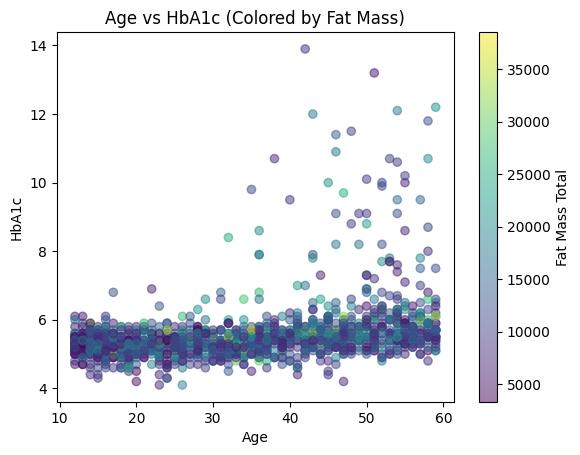

In [144]:
# Code by Caitlyn
plt.scatter(
    hf_glu["age"],
    hf_glu["hba1c"],
    c=hf_glu["fat_mass_total"],
    cmap="viridis",
    alpha=0.5
)

plt.colorbar(label="Fat Mass Total")

plt.xlabel("Age")
plt.ylabel("HbA1c")
plt.title("Age vs HbA1c (Colored by Fat Mass)")

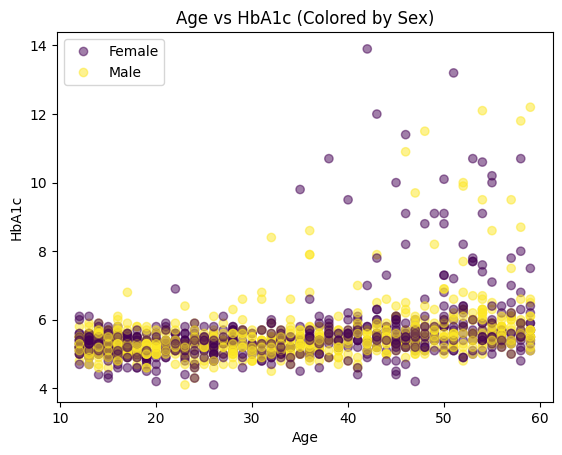

In [145]:
#Code by Caitlyn
# scatterplot of age vs hba1c by sex
scatter = plt.scatter(
    hf_glu["age"],
    hf_glu["hba1c"],
    c=hf_glu["sex"],
    cmap="viridis",
    alpha=0.5
)

plt.xlabel("Age")
plt.ylabel("HbA1c")
plt.title("Age vs HbA1c (Colored by Sex)")

handles, labels = scatter.legend_elements()

plt.legend(handles, ["Female","Male"])

plt.show()

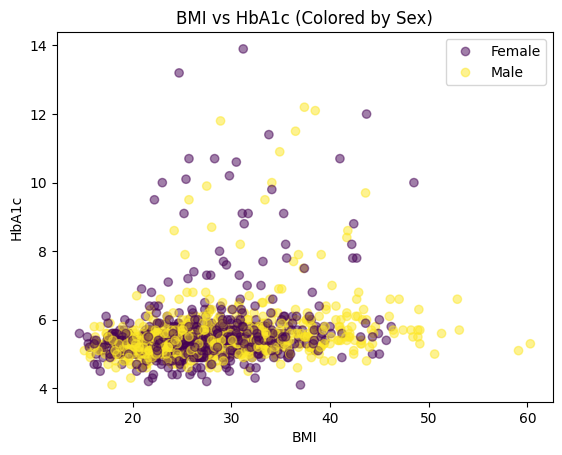

In [146]:
# scatterplot of BMI vs hba1c by sex
scatter = plt.scatter(
    hf_glu["bmi"],
    hf_glu["hba1c"],
    c=hf_glu["sex"],
    cmap="viridis",
    alpha=0.5
)

plt.xlabel("BMI")
plt.ylabel("HbA1c")
plt.title("BMI vs HbA1c (Colored by Sex)")

handles, labels = scatter.legend_elements()

plt.legend(handles, ["Female","Male"])

plt.show()

### 7.) VIF factors for your predictor set.  If any are above 10, that’s a flag we need to discuss in the report


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Variance Inflation Factors: 
        Feature        VIF
  left_leg_lean        inf
 right_leg_lean        inf
lean_mass_total        inf
 fat_mass_total        inf
 right_arm_lean        inf
  left_arm_lean        inf
  right_leg_fat        inf
   left_leg_fat        inf
  right_arm_fat        inf
   left_arm_fat        inf
      weight_kg 174.185651
            bmi 114.648851
      height_cm  22.410247
       waist_cm  18.292219
 lean_fat_ratio   5.909889
            sex   3.869632
            age   1.568336
fasting_glucose   1.207223


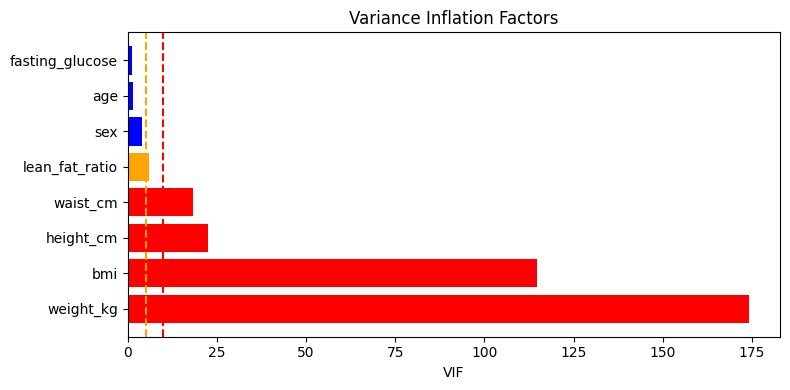

In [147]:
# Code by Bonnie
from statsmodels.stats.outliers_influence import variance_inflation_factor

predictor_cols = ["age",	"sex",	"bmi",	"waist_cm",	"weight_kg",	"height_cm",	"left_arm_lean",	"right_arm_lean",	"left_leg_lean",	"right_leg_lean",	"left_arm_fat",	"right_arm_fat",	"left_leg_fat",	"right_leg_fat",	"lean_mass_total",	"fat_mass_total",	"lean_fat_ratio",	"fasting_glucose"]
vif_data = hf_glu[predictor_cols].dropna()
vif_data = sm.add_constant(vif_data)

vif_df = pd.DataFrame({
    "Feature":vif_data.columns,
    "VIF": [variance_inflation_factor(vif_data.values,i)
    for i in range(vif_data.shape[1])]

}).query("Feature != 'const'").sort_values("VIF",ascending = False)

print(f"Variance Inflation Factors: ")
print(vif_df.to_string(index=False))

fig,ax = plt.subplots(figsize=(8,4))
colors = ["red" if v > 10 else "orange" if v > 5 else "blue"
  for v in vif_df["VIF"]]

ax.barh(vif_df["Feature"], vif_df["VIF"], color = colors)
ax.axvline(x=5, color = "orange", linestyle="--", label="Moderate")
ax.axvline(x=10, color = "red", linestyle="--", label ="Severe")
ax.set_xlabel("VIF")
ax.set_title("Variance Inflation Factors")
plt.tight_layout()
plt.show()



Weight, height and BMI are measuring the same thing.  BMI = weight/height so including all three is like telling the model the same thing three times for OLS model.  

For our OLS model we will be using age, sex, bmi, waist_cm.  We can drop weight_kg and height cm. This matters when it comes for OLS where multicollinearity makes coefficients unstable and uninterperatable.  However  other models like PCA and K means clustering this can add information as they are not affected by multicollinearity.  

# Given what we learned, this is our databse

# Model Building

In [148]:
# Code by Caitlyn
import statsmodels.api as sm

X = hf_glu[["age", "bmi", "waist_cm", "weight_kg", "height_cm"]]
X = sm.add_constant(X)

y = hf_glu["hba1c"]

ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  hba1c   R-squared:                       0.151
Model:                            OLS   Adj. R-squared:                  0.148
Method:                 Least Squares   F-statistic:                     48.75
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           1.55e-46
Time:                        05:45:09   Log-Likelihood:                -1726.2
No. Observations:                1376   AIC:                             3464.
Df Residuals:                    1370   BIC:                             3496.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.3038      1.767      3.002      0.0

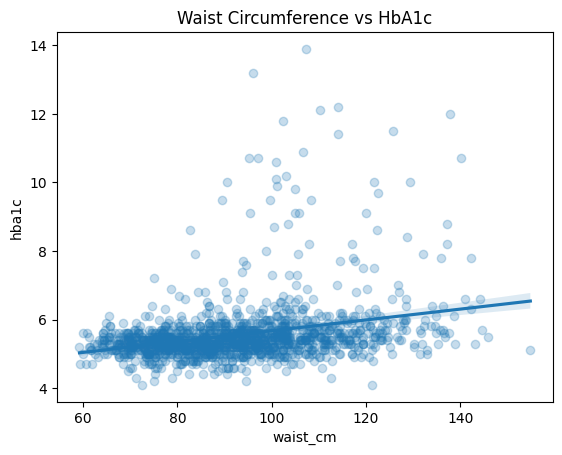

In [149]:
# Code by Caitlyn
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(
    data=hf_glu,
    x="waist_cm",
    y="hba1c",
    scatter_kws={"alpha":0.25}
)

plt.title("Waist Circumference vs HbA1c")
plt.show()

In [150]:
# Code by Caitlyn
pd.read_sql("""
SELECT *
FROM health_features
LIMIT 10
""", engine)

df = pd.read_sql("""
SELECT *
FROM health_features
""", engine)

print(df.shape)
df.head()

from sqlalchemy import text

with engine.begin() as conn:
    conn.execute(text("DROP TABLE IF EXISTS health_features"))

with engine.begin() as conn:
    conn.execute(text("""
        CREATE TABLE health_features AS
        SELECT
            p.seqn,
            p.age,
            p.sex,
            b.bmi,
            b.waist_cm,
            b.weight_kg,
            b.height_cm,
            l.hba1c
        FROM person p
        JOIN body_comp b
            ON p.seqn = b.seqn
        JOIN labs l
            ON p.seqn = l.seqn
        WHERE
            b.bmi IS NOT NULL
            AND b.waist_cm IS NOT NULL
            AND l.hba1c IS NOT NULL
    """))

print("health_features created successfully.")

(5738, 8)
health_features created successfully.


In [151]:
df.head()

,seqn,age,sex,bmi,waist_cm,weight_kg,height_cm,hba1c
0,93705,66,2,31.7,101.8,79.5,158.3,6.2
1,93706,18,1,21.5,79.3,66.3,175.7,5.2
2,93707,13,1,18.1,64.1,45.4,158.4,5.6
3,93708,66,2,23.7,88.2,53.5,150.2,6.2
4,93709,75,2,38.9,113.0,88.8,151.1,6.3


In [152]:
# Random Forest model
# Code by Caitlyn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

X = hf_glu[["bmi", "waist_cm", "weight_kg", "height_cm", "age"]]
y = hf_glu["hba1c"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print("R²:", r2_score(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("MAE:", mean_absolute_error(y_test, pred))

R²: 0.0631041785068347
RMSE: 0.8026234676090921
MAE: 0.4317149758454104


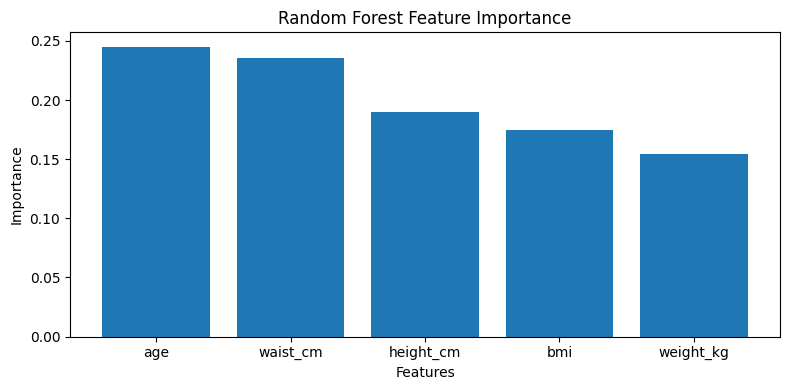

In [153]:
#Code by Caitlyn
importances = rf.feature_importances_
feature_names = X.columns

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})


feat_imp = feat_imp.sort_values("importance", ascending=False)


plt.figure(figsize=(8,4))
plt.bar(feat_imp["feature"], feat_imp["importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# MODEL ANALYSIS

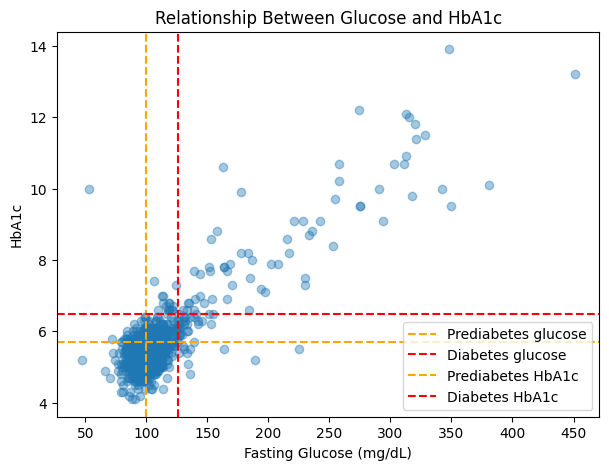

In [154]:
# Code by Caitlyn
plt.figure(figsize=(7,5))

plt.scatter(
    hf_glu["fasting_glucose"],
    hf_glu["hba1c"],
    alpha=0.4
)

plt.axvline(100, linestyle="--", color="orange", label="Prediabetes glucose")
plt.axvline(126, linestyle="--", color="red", label="Diabetes glucose")

plt.axhline(5.7, linestyle="--", color="orange", label="Prediabetes HbA1c")
plt.axhline(6.5, linestyle="--", color="red", label="Diabetes HbA1c")

plt.xlabel("Fasting Glucose (mg/dL)")
plt.ylabel("HbA1c")

plt.title("Relationship Between Glucose and HbA1c")

plt.legend()

plt.show()

In [155]:
# Code by Caitlyn
# Step 1: Drop rows where key target variables are missing
# (no point imputing the thing we're trying to predict)
hf_glu = hf_glu.dropna(subset=["hba1c", "fasting_glucose"])

print(f"Rows after dropping missing targets: {len(hf_glu)}")

# Step 2: Drop rows where core features are missing
core_features = ["bmi", "waist_cm", "fat_mass_total",
                 "lean_mass_total", "age", "sex"]

hf_glu = hf_glu.dropna(subset=core_features)

print(f"Rows after dropping missing features: {len(hf_glu)}")

# Step 3: Check what's left
print(f"\nRemaining NAs per column:")
print(hf_glu.isnull().sum()[hf_glu.isnull().sum() > 0])

Rows after dropping missing targets: 1376
Rows after dropping missing features: 1376

Remaining NAs per column:
Series([], dtype: int64)


PCA Explained Variance: 
PC1: 0.5045251992601407 cumulative: 0.5045251992601407
PC2: 0.27631323033737215 cumulative: 0.7808384295975128
PC3: 0.14692984760112335 cumulative: 0.9277682771986362
PC4: 0.06148621476135965 cumulative: 0.9892544919599958
PC5: 0.009961083185044548 cumulative: 0.9992155751450403
PC6: 0.000784424854959615 cumulative: 1.0


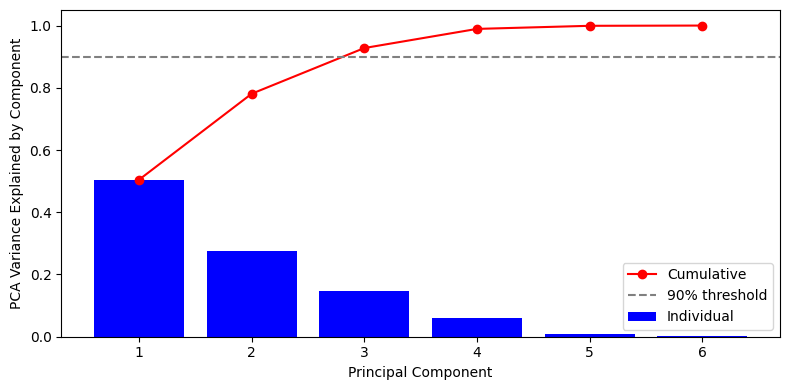

Adjusted score: 0.022249731913049034
actual     0   1   2
cluster             
0        278  21   2
1        131  74  35
2        362  93  28
3        253  79  20


In [156]:
# Code by Bonnie
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_cols = ['age','sex','bmi','waist_cm','weight_kg','height_cm']
pca_data = hf_glu[pca_cols].dropna()

scaler = StandardScaler()
scaled = scaler.fit_transform(pca_data)
pca = PCA()
pca.fit(scaled)
explained = pca.explained_variance_ratio_
cumulative = explained.cumsum()
print("PCA Explained Variance: ")

for i, (exp,cum) in enumerate(zip(explained,cumulative)):
  print(f"PC{i+1}: {exp} cumulative: {cum}")


fig, ax = plt.subplots(figsize=(8,4))
ax.bar(range(1,len(explained)+1), explained, color = "blue", label = "Individual")
ax.plot(range(1,len(cumulative)+1),cumulative, color = "red", marker = "o", label ="Cumulative" )
ax.axhline(y = 0.90, color="gray",linestyle='--', label = '90% threshold')
ax.set_xlabel("Principal Component")
ax.set_ylabel("PCA Variance Explained by Component")
ax.legend()
plt.tight_layout()
plt.show()

kmeans = KMeans(n_clusters=4,random_state = 42)
pca_clusters = kmeans.fit_predict(scaled)
from sklearn.metrics import adjusted_rand_score
pca_data['cluster'] = pca_clusters

pca_data['actual'] = hf_glu.loc[pca_data.index,'hba1c'].apply(
    lambda x: 0 if x < 5.7 else 1 if x < 6.5 else 2
)
print(f"Adjusted score: {adjusted_rand_score(pca_data['actual'],pca_clusters)}" )
print(pd.crosstab(pca_data["cluster"],pca_data['actual']))



In [157]:
# Code by Caitlyn
cluster_df = hf_glu[["waist_cm","lean_fat_ratio","hba1c"]].dropna()

In [158]:
# Code by Caitlyn
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(cluster_df)

In [159]:
# Code by Caitlyn
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)

cluster_df["cluster"] = kmeans.fit_predict(X)

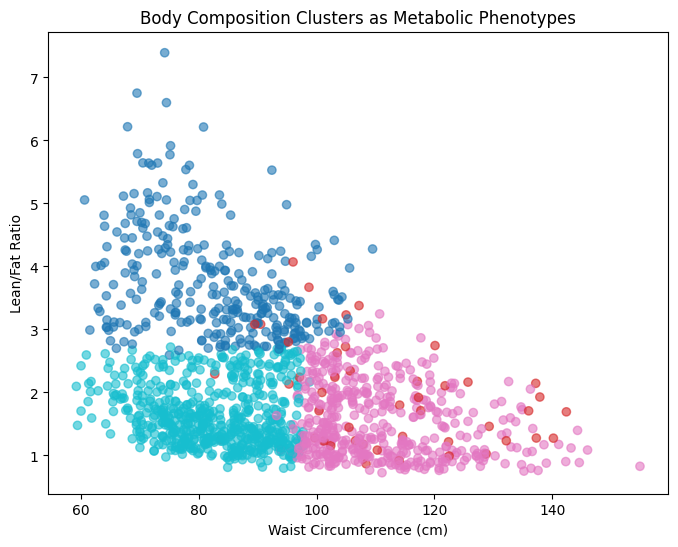

In [160]:
# Code by Caitlyn
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    cluster_df["waist_cm"],
    cluster_df["lean_fat_ratio"],
    c=cluster_df["cluster"],
    cmap="tab10",
    alpha=0.6
)

plt.xlabel("Waist Circumference (cm)")
plt.ylabel("Lean/Fat Ratio")
plt.title("Body Composition Clusters as Metabolic Phenotypes")

plt.show()

In [161]:
cluster_summary = cluster_df.groupby("cluster").mean()

cluster_summary

,waist_cm,lean_fat_ratio,hba1c
cluster,,,
0,82.716776,3.724778,5.393092
1,111.543478,1.963268,9.636957
2,110.649666,1.551180,5.586860
3,82.825823,1.646954,5.308146


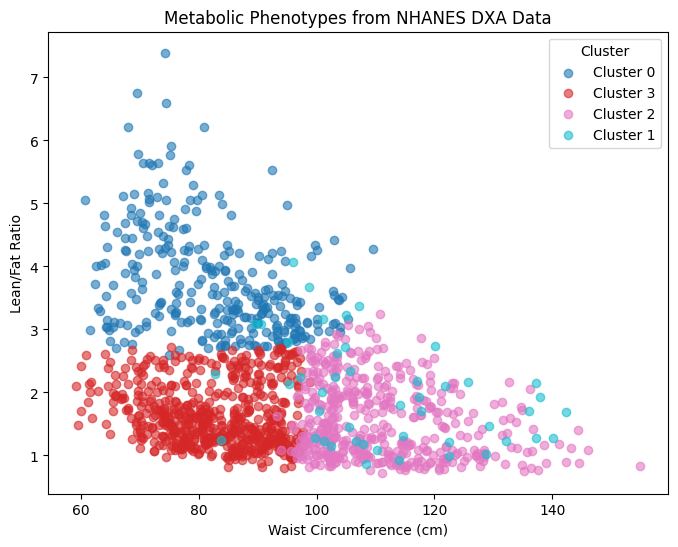

In [162]:
# Code by Caitlyn
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

clusters = cluster_df["cluster"].unique()
colors = plt.cm.tab10(np.linspace(0,1,len(clusters)))

for c, color in zip(clusters, colors):

    subset = cluster_df[cluster_df["cluster"] == c]

    plt.scatter(
        subset["waist_cm"],
        subset["lean_fat_ratio"],
        color=color,
        alpha=0.6,
        label=f"Cluster {c}"
    )

plt.xlabel("Waist Circumference (cm)")
plt.ylabel("Lean/Fat Ratio")
plt.title("Metabolic Phenotypes from NHANES DXA Data")

plt.legend(title="Cluster")

plt.show()

Smaller waist circumference usually means higher lean/fat ratio (more muscle compared to body fat).
There are 4 clusters:

0) low waist circumference + high lean/fat ratio (dark blue)
1) high waist circumference + moderate lean/fat ratio (light blue)
2) high waist circumference + low lean/fat ratio (pink)
3) low waist circumference + low lean/fat ratio (red)

In [163]:
# Code by Caitlyn
labels = {
0:"Lean Healthy",
1:"High Visceral Fat",
2:"Intermediate",
3:"Low Lean Mass"
}
# add a phenotype label to the cluster column
cluster_df["phenotype"] = cluster_df["cluster"].map(labels)
print(cluster_df.head())

   waist_cm  lean_fat_ratio  hba1c  cluster      phenotype
0      86.6        3.402517    5.7        0   Lean Healthy
1      86.2        3.322460    5.1        0   Lean Healthy
2      86.0        1.569587    5.0        3  Low Lean Mass
3     101.7        2.065459    4.9        2   Intermediate
4     102.7        3.093707    5.6        0   Lean Healthy


In [164]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd

phase_df = hf_glu[["waist_cm", "lean_fat_ratio", "hba1c"]].dropna().copy()

X2 = phase_df[["waist_cm", "lean_fat_ratio"]]

scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

kmeans2 = KMeans(n_clusters=4, random_state=42, n_init=10)
phase_df["cluster"] = kmeans2.fit_predict(X2_scaled)
print(phase_df)

      waist_cm  lean_fat_ratio  hba1c  cluster
0         86.6        3.402517    5.7        0
1         86.2        3.322460    5.1        0
2         86.0        1.569587    5.0        3
3        101.7        2.065459    4.9        0
4        102.7        3.093707    5.6        0
...        ...             ...    ...      ...
1371     128.0        1.423037    5.9        2
1372      75.0        1.513643    5.5        3
1373      96.7        3.390714    5.2        0
1374      75.2        2.720015    4.4        0
1375      69.7        2.026720    5.2        3

[1376 rows x 4 columns]


In [165]:
cluster_summary = phase_df.groupby("cluster")[["waist_cm", "lean_fat_ratio", "hba1c"]].mean().sort_values(["waist_cm", "lean_fat_ratio"])
cluster_summary

,waist_cm,lean_fat_ratio,hba1c
cluster,,,
1,74.973585,4.236312,5.337107
3,81.386519,1.533138,5.343260
0,94.250162,2.798335,5.677346
2,112.544769,1.384881,5.828710


In [166]:
# Code by Caitlyn
labels = {
    1: "Lean Healthy",
    3: "Low Lean Mass",
    0: "Intermediate Risk",
    2: "High Visceral Fat"
}

phase_df["phenotype"] = phase_df["cluster"].map(labels)

MODELING FOR FINAL MERGED DATASET

In [167]:
# Code by Caitlyn
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import statsmodels.api as sm
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression
results = []

Average CV R2: 0.16556110110375377


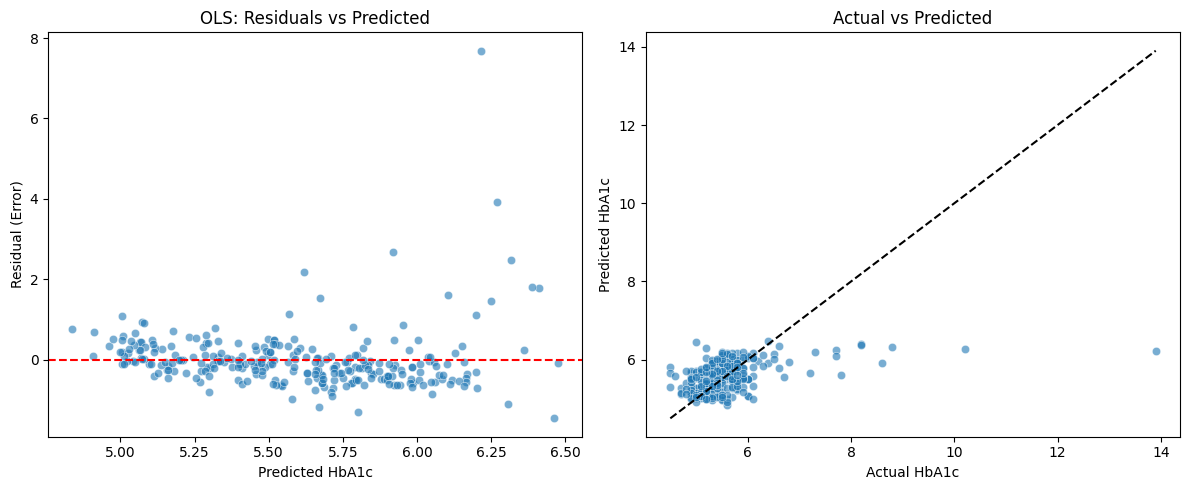

In [168]:
# OLS model
# Code by Caitlyn

X = hf_glu[["age", "bmi", "waist_cm", "fat_mass_total", "lean_mass_total"]]
y = hf_glu["hba1c"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

ols = sm.OLS(y_train, X_train_sm).fit()

ols_preds = ols.predict(X_test_sm)

lr = LinearRegression()

cv_scores = cross_val_score(lr, X_train, y_train, cv=5, scoring='r2')
print("Average CV R2:", cv_scores.mean())


results.append([
    "OLS",
    r2_score(y_test, ols_preds),
    np.sqrt(mean_squared_error(y_test, ols_preds)),
    mean_absolute_error(y_test, ols_preds),
    ols.aic
])


# plot the residuals
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# 1. Calculate residuals
residuals = y_test - ols_preds

plt.figure(figsize=(12, 5))

# Plot 1: Residuals vs Predicted (Testing for Linearity)
plt.subplot(1, 2, 1)
sns.scatterplot(x=ols_preds, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title('OLS: Residuals vs Predicted')
plt.xlabel('Predicted HbA1c')
plt.ylabel('Residual (Error)')

# Plot 2: Actual vs Predicted
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=ols_preds, alpha=0.6)
# Add the identity line (perfect prediction)
line_coords = np.linspace(min(y_test.min(), ols_preds.min()), max(y_test.max(), ols_preds.max()))
plt.plot(line_coords, line_coords, color='black', linestyle='--')
plt.title('Actual vs Predicted')
plt.xlabel('Actual HbA1c')
plt.ylabel('Predicted HbA1c')

plt.tight_layout()
plt.show()

Average CV R2: 0.1433120282435521


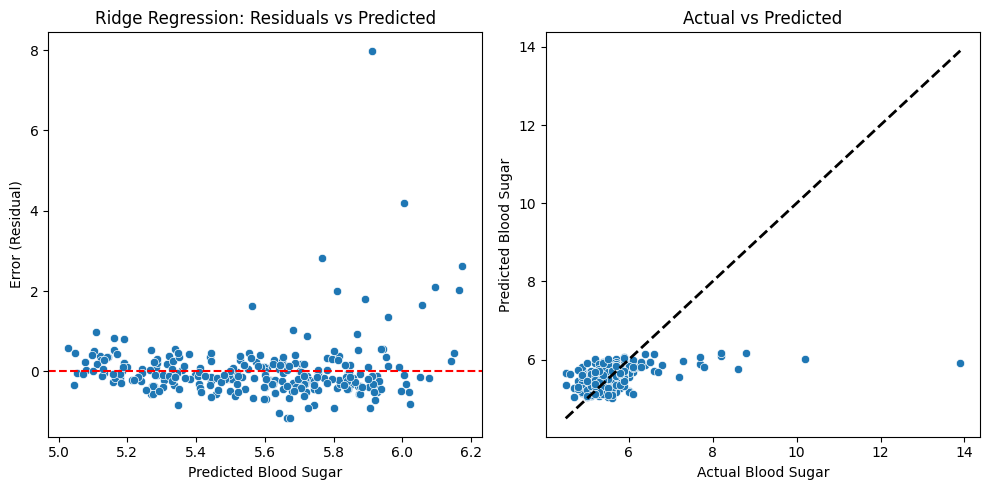

In [169]:
# Lasso Regression
# Code by Caitlyn

X = hf_glu[["age", "bmi", "waist_cm", "fat_mass_total", "lean_mass_total"]]
y = hf_glu["hba1c"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lasso = Lasso(alpha=1.0)
scores = cross_val_score(lasso, X_train, y_train, cv=5, scoring='r2')
print("Average CV R2:", scores.mean())
lasso.fit(X_train, y_train)

lasso_preds = lasso.predict(X_test)

rss = np.sum((y_test - lasso_preds)**2)
n = len(y_test)


k = X_train.shape[1]   # number of predictors
aic_lasso = n * np.log(rss/n) + 2*k

results.append([
    "Lasso",
    r2_score(y_test, lasso_preds),
    np.sqrt(mean_squared_error(y_test, lasso_preds)),
    mean_absolute_error(y_test, lasso_preds),
    aic_lasso
])


# plot the residuals

# Assuming 'y_test' are actual values and 'ridge_preds' are your model's predictions
residuals = y_test - lasso_preds

plt.figure(figsize=(10, 5))

# Residual Plot
plt.subplot(1, 2, 1)
sns.scatterplot(x=lasso_preds, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Ridge Regression: Residuals vs Predicted')
plt.xlabel('Predicted Blood Sugar')
plt.ylabel('Error (Residual)')

# Prediction Error Plot
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=lasso_preds)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Actual vs Predicted')
plt.xlabel('Actual Blood Sugar')
plt.ylabel('Predicted Blood Sugar')

plt.tight_layout()
plt.show()

Average CV R2: 0.16556254230866863


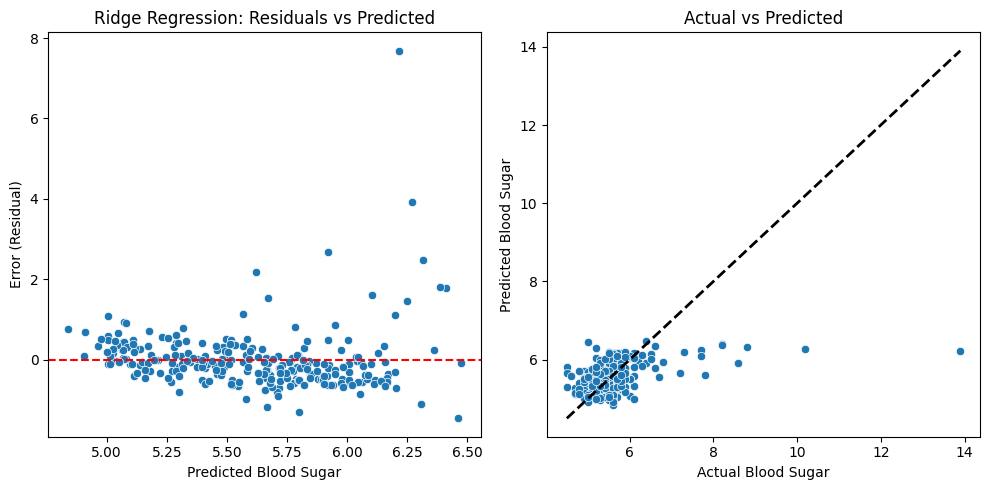

In [170]:
# Ridge Regression

X = hf_glu[["age", "bmi", "waist_cm", "fat_mass_total", "lean_mass_total"]]
y = hf_glu["hba1c"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

ridge = Ridge(alpha=1.0)
scores = cross_val_score(ridge, X_train, y_train, cv=5, scoring='r2')
print("Average CV R2:", scores.mean())
ridge.fit(X_train, y_train)

ridge_preds = ridge.predict(X_test)

rss = np.sum((y_test - ridge_preds)**2)
n = len(y_test)


k = X_train.shape[1]   # number of predictors
aic_ridge = n * np.log(rss/n) + 2*k

results.append([
    "Ridge",
    r2_score(y_test, ridge_preds),
    np.sqrt(mean_squared_error(y_test, ridge_preds)),
    mean_absolute_error(y_test, ridge_preds),
    aic_ridge
])


# plot the residuals

# Assuming 'y_test' are actual values and 'ridge_preds' are your model's predictions
residuals = y_test - ridge_preds

plt.figure(figsize=(10, 5))

# Residual Plot
plt.subplot(1, 2, 1)
sns.scatterplot(x=ridge_preds, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Ridge Regression: Residuals vs Predicted')
plt.xlabel('Predicted Blood Sugar')
plt.ylabel('Error (Residual)')

# Prediction Error Plot
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=ridge_preds)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title('Actual vs Predicted')
plt.xlabel('Actual Blood Sugar')
plt.ylabel('Predicted Blood Sugar')

plt.tight_layout()
plt.show()

Average CV R2: 0.05191334828179002


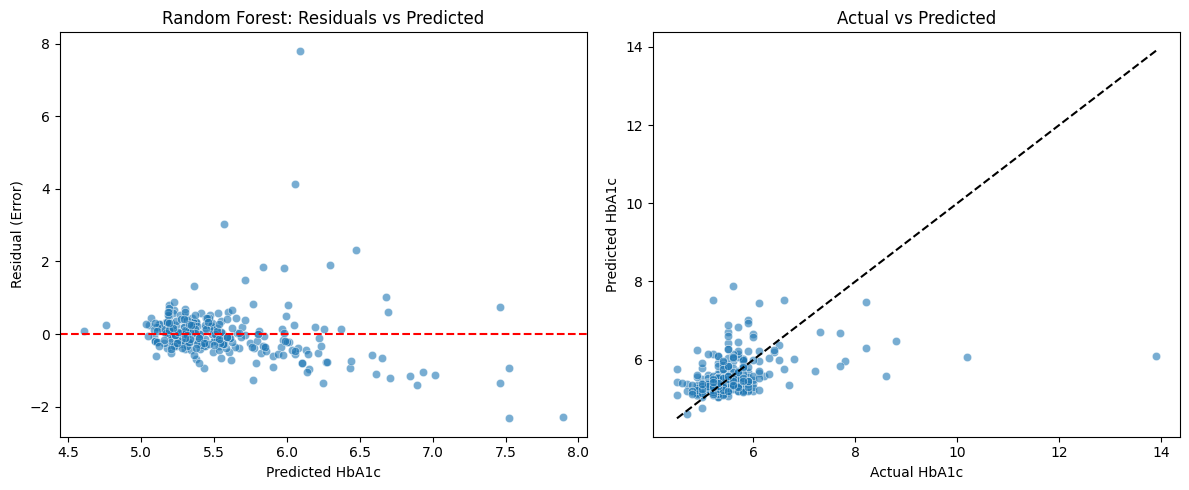

In [171]:
# Random Forest model
# # Code by Caitlyn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

X = hf_glu[["age", "bmi", "waist_cm", "fat_mass_total", "lean_mass_total"]]
y = hf_glu["hba1c"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf_fit = rf.fit(X_train, y_train)


cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')
print("Average CV R2:", cv_scores.mean())

rf_preds = rf.predict(X_test)

results.append([
    "Random Forest",
    r2_score(y_test, rf_preds),
    np.sqrt(mean_squared_error(y_test, rf_preds)),
    mean_absolute_error(y_test, rf_preds),
    None # RF has no AIC
])


# residuals
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# calculate residuals
residuals = y_test - rf_preds

plt.figure(figsize=(12, 5))

# Plot 1: Residuals vs Predicted
plt.subplot(1, 2, 1)
sns.scatterplot(x=rf_preds, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title('Random Forest: Residuals vs Predicted')
plt.xlabel('Predicted HbA1c')
plt.ylabel('Residual (Error)')

# Plot 2: Actual vs Predicted
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=rf_preds, alpha=0.6)
# Add the identity line (perfect prediction)
line_coords = np.linspace(min(y_test.min(), rf_preds.min()), max(y_test.max(), rf_preds.max()))
plt.plot(line_coords, line_coords, color='black', linestyle='--')
plt.title('Actual vs Predicted')
plt.xlabel('Actual HbA1c')
plt.ylabel('Predicted HbA1c')

plt.tight_layout()
plt.show()

Average CV R2: -0.02816484708030915


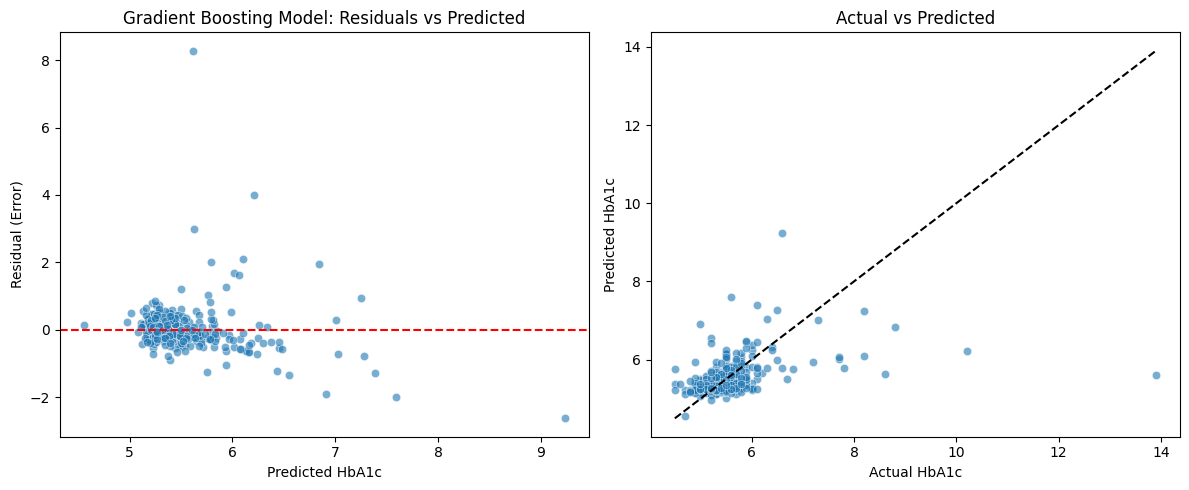

In [172]:
# Gradient Boosting Model
# Code by Caitlyn
from sklearn.ensemble import GradientBoostingRegressor

X = hf_glu[["age", "bmi", "waist_cm", "fat_mass_total", "lean_mass_total"]]
y = hf_glu["hba1c"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)

cv_scores = cross_val_score(gb, X_train, y_train, cv=5, scoring='r2')
print("Average CV R2:", cv_scores.mean())


gb_preds = gb.predict(X_test)

n = len(y_test)
mse = mean_squared_error(y_test, gb_preds)
k = gb.n_estimators * gb.max_depth   # common proxy
aic_gb = n * np.log(mse) + 2*k


results.append([
    "Gradient Boosting",
    r2_score(y_test, gb_preds),
    np.sqrt(mean_squared_error(y_test, gb_preds)),
    mean_absolute_error(y_test, gb_preds),
    aic_gb
])


# plot the residuals
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# 1. Calculate residuals
residuals = y_test - gb_preds

plt.figure(figsize=(12, 5))

# Plot 1: Residuals vs Predicted (Testing for Linearity)
plt.subplot(1, 2, 1)
sns.scatterplot(x=gb_preds, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title('Gradient Boosting Model: Residuals vs Predicted')
plt.xlabel('Predicted HbA1c')
plt.ylabel('Residual (Error)')

# Plot 2: Actual vs Predicted
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=gb_preds, alpha=0.6)
# Add the identity line (perfect prediction)
line_coords = np.linspace(min(y_test.min(), pred.min()), max(y_test.max(), pred.max()))
plt.plot(line_coords, line_coords, color='black', linestyle='--')
plt.title('Actual vs Predicted')
plt.xlabel('Actual HbA1c')
plt.ylabel('Predicted HbA1c')

plt.tight_layout()
plt.show()

Average CV R2: -0.057942629733717554


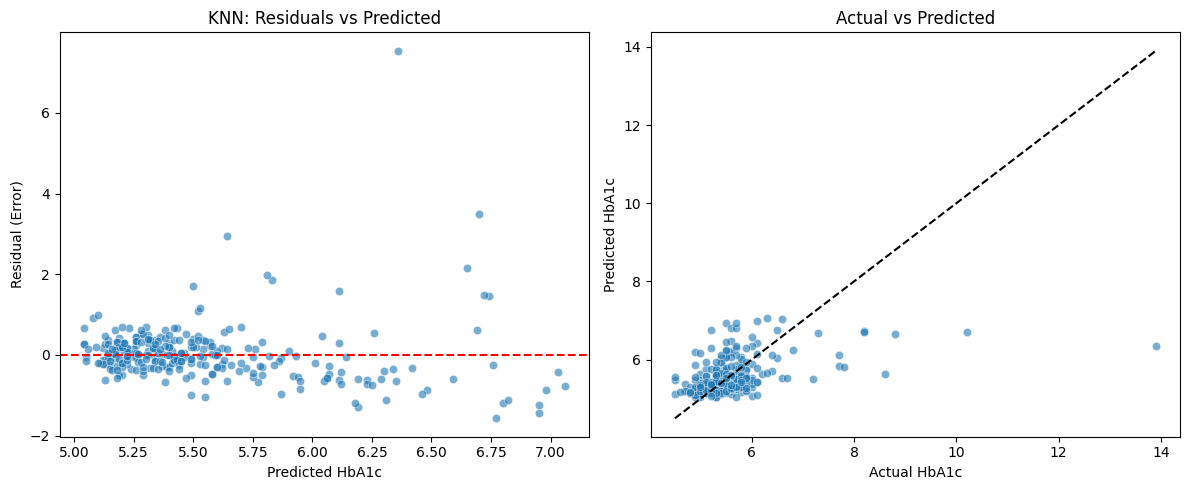

In [173]:
# KNN model
# Code by Caitlyn
from sklearn.neighbors import KNeighborsRegressor

X = hf_glu[["age", "bmi", "waist_cm", "fat_mass_total", "lean_mass_total"]]
y = hf_glu["hba1c"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsRegressor(n_neighbors=10)
knn.fit(X_train_scaled, y_train)

cv_scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='r2')
print("Average CV R2:", cv_scores.mean())

knn_preds = knn.predict(X_test_scaled)

n = len(y_test)

mse = mean_squared_error(y_test, knn_preds)
k = knn.n_neighbors

aic_knn = n * np.log(mse) + 2*k

results.append([
    "K Nearest Neighbors",
    r2_score(y_test, knn_preds),
    np.sqrt(mean_squared_error(y_test, knn_preds)),
    mean_absolute_error(y_test, knn_preds),
    aic_knn
])


# plot the residuals


import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# 1. Calculate residuals
residuals = y_test - knn_preds

plt.figure(figsize=(12, 5))

# Plot 1: Residuals vs Predicted (Testing for Linearity)
plt.subplot(1, 2, 1)
sns.scatterplot(x=knn_preds, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title('KNN: Residuals vs Predicted')
plt.xlabel('Predicted HbA1c')
plt.ylabel('Residual (Error)')

# Plot 2: Actual vs Predicted
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=knn_preds, alpha=0.6)
# Add the identity line (perfect prediction)
line_coords = np.linspace(min(y_test.min(), pred.min()), max(y_test.max(), pred.max()))
plt.plot(line_coords, line_coords, color='black', linestyle='--')
plt.title('Actual vs Predicted')
plt.xlabel('Actual HbA1c')
plt.ylabel('Predicted HbA1c')

plt.tight_layout()
plt.show()

Average CV R2: 0.16239239184804474


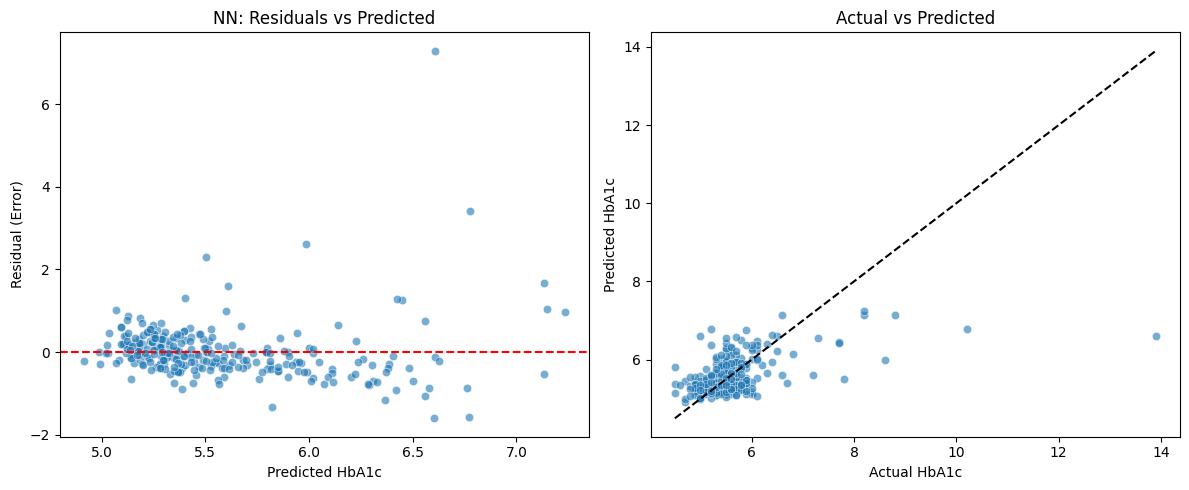

In [174]:
# Code by Caitlyn
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# fit a Neural Network

X = hf_glu[["age", "bmi", "waist_cm", "fat_mass_total", "lean_mass_total"]]
y = hf_glu["hba1c"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

nn = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(64,32),
        activation='relu',
        solver='adam',
        max_iter=2000,
        random_state=42
    ))
])

nn.fit(X_train, y_train)

cv_scores = cross_val_score(nn, X_train, y_train, cv=5, scoring='r2')
print("Average CV R2:", cv_scores.mean())

nn_preds = nn.predict(X_test)

n = len(y_test)

mse = mean_squared_error(y_test, nn_preds)
k_values = range(20,150,5) # test a range of k values

aic_nn = n * np.log(mse) + 2*k

results.append([
    "Neural Network",
    r2_score(y_test, nn_preds),
    np.sqrt(mean_squared_error(y_test, nn_preds)),
    mean_absolute_error(y_test, nn_preds),
    aic_nn
])


# plot the residuals


import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# 1. Calculate residuals
residuals = y_test - nn_preds

plt.figure(figsize=(12, 5))

# Plot 1: Residuals vs Predicted (Testing for Linearity)
plt.subplot(1, 2, 1)
sns.scatterplot(x=nn_preds, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title('NN: Residuals vs Predicted')
plt.xlabel('Predicted HbA1c')
plt.ylabel('Residual (Error)')

# Plot 2: Actual vs Predicted
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=nn_preds, alpha=0.6)
# Add the identity line (perfect prediction)
line_coords = np.linspace(min(y_test.min(), pred.min()), max(y_test.max(), pred.max()))
plt.plot(line_coords, line_coords, color='black', linestyle='--')
plt.title('Actual vs Predicted')
plt.xlabel('Actual HbA1c')
plt.ylabel('Predicted HbA1c')

plt.tight_layout()
plt.show()

                 Model   Test R²      RMSE       MAE          AIC
6       Neural Network  0.276274  0.705429  0.406999  -172.619784
5  K Nearest Neighbors  0.191973  0.745382  0.425870  -142.209560
2                Ridge  0.176226  0.752610  0.430141  -146.882645
0                  OLS  0.176224  0.752611  0.430144  2783.830386
1                Lasso  0.163158  0.758557  0.409130  -142.538437
4    Gradient Boosting  0.109497  0.782499  0.416496   464.615032
3        Random Forest  0.104850  0.784538  0.437676          NaN


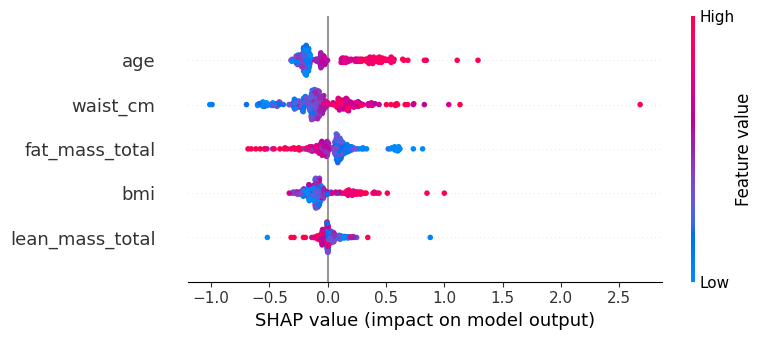

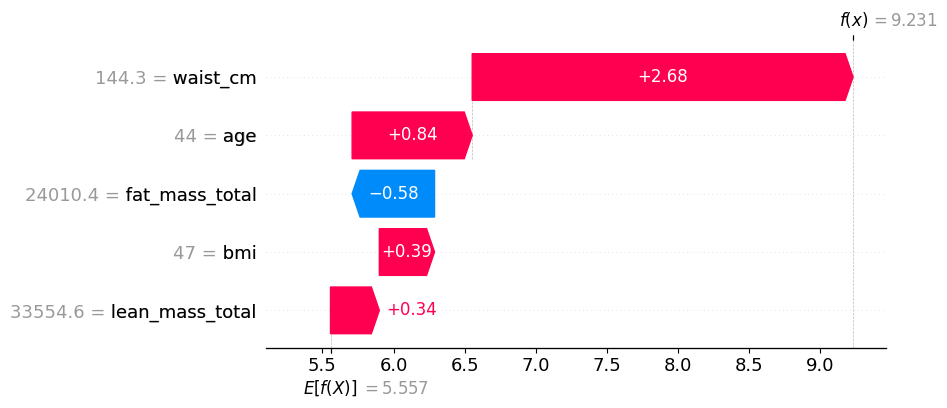

In [175]:
# Code by Caitlyn
import shap

results_df = pd.DataFrame(
    results,
    columns=["Model","Test R²","RMSE","MAE", "AIC"]
)

results_df.sort_values("RMSE")



# this removes rows where all columns are identical
results_df = results_df.drop_duplicates()
results_df = results_df.sort_values(by='Test R²', ascending=False)
results_df = results_df.drop_duplicates(subset=['Model'])
print(results_df)


# Bonnie Lines 21 - 30
explainer = shap.TreeExplainer(gb)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)
high_risk_idx = np.argmax(gb.predict(X_test))
shap.waterfall_plot(shap.Explanation(values = shap_values[high_risk_idx],
  base_values=explainer.expected_value,
  data = X_test.iloc[high_risk_idx],
  feature_names = X_test.columns.tolist()
  ))


In [176]:
# calculate prediction accuracy in percentage
# Code by Caitlyn
accuracy_percent = 100 * (1 - np.mean(np.abs(y_test - nn_preds) / y_test))
print(f"Approximate prediction accuracy: {accuracy_percent:.2f}%")

Approximate prediction accuracy: 93.21%


OLS and Ridge Regression are both tied for best performance on the test data, with an R^2 of 0.176, RMSE of 0.75, and MAE of 0.43. However, for real-world deployment, Ridge Regression is better since it avoids overfitting by preventing the model from becoming overly sensitive to new patient data. It also has better fitting points for actual values vs model predictions. Therefore, we will use the Ridge Regression model as our final prediction model for blood glucose levels based on predictors such as age, BMI, and fat_mass_total.

In [177]:
# Code by Caitlyn
import pandas as pd
# predict blood sugar level given a patient's data
# 1. Define the patient's data
# Example: Age=25, BMI=28, Waist=95cm, FatMass=25kg, LeanMass=55k
new_patient_data = pd.DataFrame([[25.0, 28.0, 95.0, 25.0, 55.0]],
                                columns=["age", "bmi", "waist_cm", "fat_mass_total", "lean_mass_total"])

# 2. Make the prediction
prediction = ridge.predict(new_patient_data)

print(f"The predicted HbA1c level is: {prediction[0]:.2f}")

The predicted HbA1c level is: 6.84


In [178]:
# Code by Caitlyn
import pandas as pd

print("Enter patient information:")

age = float(input("Age: "))
bmi = float(input("BMI: "))
waist = float(input("Waist circumference (cm): "))
fat = float(input("Fat mass (kg): "))
lean = float(input("Lean mass (kg): "))

# Create dataframe in same format as training data
new_patient = pd.DataFrame(
    [[age, bmi, waist, fat, lean]],
    columns=["age", "bmi","waist_cm","fat_mass_total","lean_mass_total"]
)

# predict HbA1c
prediction = ridge.predict(new_patient)

hba1c = prediction[0]


print("\nAnalyzing metabolic profile...\n")

# determine diabetes risk category
if hba1c < 5.7:
    risk = "Low Risk"
    message = "Your HbA1c is within the normal range."
elif hba1c < 6.5:
    risk = "Prediabetes Risk"
    message = "Your HbA1c suggests prediabetes risk. Lifestyle changes may help."
else:
    risk = "High Diabetes Risk"
    message = "Your HbA1c is in the diabetes range. Please consult a healthcare professional."

# print results
print(f"Predicted HbA1c: {hba1c:.2f}")
print(f"Risk Category: {risk}")
print(message)


risk_score = min(max((hba1c - 4) * 10, 0), 100)
print("\nRisk Meter:")
print("[" + "I" * int(risk_score/5) + "-" * (20 - int(risk_score/5)) + "]")


# give personalized advice based on person's body composition and age
if bmi >= 30:
    print("💡 Tip: BMI indicates obesity. Reducing BMI through exercise may lower diabetes risk.")

if bmi >= 25:
  print("Tip: BMI indicates overweight. Increasing physical activity may lower diabetes risk.")

# female threshold for diabetes risk
if waist >= 88:
  print("Waist circumference indicates high visceral fat. Increasing physical activity may lower diabetes risk.")

# male threshold for diabetes risk
if waist >= 102:
  print("Waist circumference indicates high visceral fat. Increasing physical activity may lower diabetes risk.")

# higher lean mass = lower risk of type 2 diabetes
if lean < 50:
  print("Increasing lean muscle mass can improve glucose metabolism.")

# recommend screening for age 35 and older
if age > 35:
  print("HbA1c screening is recommended for all adults 35 or older.")

Enter patient information:
Age: 23
BMI: 123
Waist circumference (cm): 32
Fat mass (kg): 45
Lean mass (kg): 32

Analyzing metabolic profile...

Predicted HbA1c: 11.07
Risk Category: High Diabetes Risk
Your HbA1c is in the diabetes range. Please consult a healthcare professional.

Risk Meter:
[IIIIIIIIIIIIII------]
💡 Tip: BMI indicates obesity. Reducing BMI through exercise may lower diabetes risk.
Tip: BMI indicates overweight. Increasing physical activity may lower diabetes risk.
Increasing lean muscle mass can improve glucose metabolism.
